In [1]:
# Task 04  ·  Full EDA Report  [Hard — Week Capstone]
# Write a complete EDA report on a real-world dataset — tell the story of the data
# Goal Fetch a real dataset from any public API, perform a full EDA, and write a clean report with
# charts and insights.
# Fetch API
# requests →Clean data
# Pandas ETL →Summary stats
# describe() →Visualise
# matplotlib →Report
# findings
# Must Fetch a new dataset — something interesting to you (sports, crypto, weather, books...)
# Must Run complete EDA checklist: shape, nulls, describe, value_counts, distributions
# Must At least 5 charts — histogram, box plot, bar chart, scatter plot, correlation heatmap
# Must All charts labelled: title, xlabel, ylabel — saved as .png files
# Must Written report (in comments or .txt): 8–10 observations from your analysis
# Should Group comparisons — compare distributions between at least 2 categories
# Bonus Use sns.pairplot() and identify the single most interesting relationship you found


## Initial Setup and Data Acquisition

Following the instructions, the first step taken was to prepare the environment for data acquisition. This involved installing the necessary Python libraries: `requests` for making HTTP requests to external APIs, and `pandas` for efficient data manipulation and analysis. These libraries are crucial for fetching and processing the anime data from the AniList API.

We utilized the **AniList API** to fetch a dataset of anime entries. This API provides comprehensive information about anime, which is ideal for an exploratory data analysis. The initial analysis performed included inspecting the dataset's structure (`df.info()`, `df.shape`), checking for and handling missing values (specifically in the `episodes` column), and generating summary statistics for both numerical and categorical features.

## Step 1: Data Acquisition

For this EDA report, I'll use the Open-Meteo API to fetch weather data. It's a free and open-source API for weather forecasts. We'll start by installing the `requests` library to interact with the API and `pandas` to handle the data.

In [ ]:
# Install necessary libraries
!pip install requests pandas json

Now, let's import the libraries and fetch some anime data using the AniList API. We'll make a GraphQL request to get a list of anime.

In [3]:
import requests
import pandas as pd
import json

# Define the AniList API endpoint
url = 'https://graphql.anilist.co'

# Define a GraphQL query to fetch some anime data (e.g., popular airing anime)
query = '''
query {
  Page (perPage: 100) {
    media (type: ANIME, sort: POPULARITY_DESC) {
      id
      title {
        romaji
        english
        native
      }
      format
      status
      episodes
      duration
      averageScore
      genres
      popularity
      seasonYear
    }
  }
}
'''

# Set headers for the request
headers = {
    'Content-Type': 'application/json',
    'Accept': 'application/json',
}

# Make the API request
response = requests.post(url, headers=headers, json={'query': query})
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
data = response.json()

# Extract anime data and convert to a pandas DataFrame
anime_list = data['data']['Page']['media']
df = pd.DataFrame(anime_list)

# Normalize nested 'title' column for better readability
df['title_romaji'] = df['title'].apply(lambda x: x.get('romaji'))
df['title_english'] = df['title'].apply(lambda x: x.get('english'))
df['title_native'] = df['title'].apply(lambda x: x.get('native'))
df = df.drop(columns=['title'])

# Display the first 5 rows of the DataFrame
display(df.head())

,id,format,status,episodes,duration,averageScore,genres,popularity,seasonYear,title_romaji,title_english,title_native
0,16498,TV,FINISHED,25.0,24,85,"[Action, Drama, Fantasy, Mystery]",996584,2013,Shingeki no Kyojin,Attack on Titan,進撃の巨人
1,101922,TV,FINISHED,26.0,24,83,"[Action, Adventure, Drama, Fantasy, Supernatural]",943227,2019,Kimetsu no Yaiba,Demon Slayer: Kimetsu no Yaiba,鬼滅の刃
2,113415,TV,FINISHED,24.0,24,84,"[Action, Drama, Supernatural]",911556,2020,Jujutsu Kaisen,JUJUTSU KAISEN,呪術廻戦
3,1535,TV,FINISHED,37.0,23,84,"[Mystery, Psychological, Supernatural, Thriller]",908141,2006,DEATH NOTE,Death Note,DEATH NOTE
4,21459,TV,FINISHED,13.0,24,77,"[Action, Adventure, Comedy]",832334,2016,Boku no Hero Academia,My Hero Academia,僕のヒーローアカデミア


## Step 2: Data Cleaning and Preparation

Now, let's examine the basic structure of our DataFrame, including its shape, data types, and a summary of non-null values. This will help us identify any potential issues that need cleaning.

In [4]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             50 non-null     int64  
 1   format         50 non-null     str    
 2   status         50 non-null     str    
 3   episodes       49 non-null     float64
 4   duration       50 non-null     int64  
 5   averageScore   50 non-null     int64  
 6   genres         50 non-null     object 
 7   popularity     50 non-null     int64  
 8   seasonYear     50 non-null     int64  
 9   title_romaji   50 non-null     str    
 10  title_english  50 non-null     str    
 11  title_native   50 non-null     str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 4.8+ KB


In [5]:
# Display the shape of the DataFrame (rows, columns)
print(f"DataFrame shape: {df.shape}")

DataFrame shape: (50, 12)


## Step 2: Data Cleaning and Preparation

Now, let's examine the basic structure of our DataFrame, including its shape, data types, and a summary of non-null values. This will help us identify any potential issues that need cleaning.

In [6]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             50 non-null     int64  
 1   format         50 non-null     str    
 2   status         50 non-null     str    
 3   episodes       49 non-null     float64
 4   duration       50 non-null     int64  
 5   averageScore   50 non-null     int64  
 6   genres         50 non-null     object 
 7   popularity     50 non-null     int64  
 8   seasonYear     50 non-null     int64  
 9   title_romaji   50 non-null     str    
 10  title_english  50 non-null     str    
 11  title_native   50 non-null     str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 4.8+ KB


In [7]:
# Display the shape of the DataFrame (rows, columns)
print(f"DataFrame shape: {df.shape}")

DataFrame shape: (50, 12)


In [8]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         1
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA) - Summary Statistics

Now that our data is clean, let's generate summary statistics for the numerical columns. This will provide insights into their distributions, central tendencies, and spread.

In [9]:
# Display descriptive statistics for numerical columns
display(df.describe())

,id,episodes,duration,averageScore,popularity,seasonYear
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000
mean,48600.260000,45.020000,29.580000,81.900000,614017.700000,2014.84000
std,46146.958493,90.644065,22.692343,4.734804,129256.366973,5.16013
min,20.000000,1.000000,23.000000,69.000000,470931.000000,1999.00000
25%,19973.000000,12.000000,24.000000,79.000000,519392.250000,2014.00000
50%,21218.000000,24.000000,24.000000,83.000000,579797.000000,2016.00000
75%,101333.750000,25.000000,24.000000,85.000000,682423.000000,2018.75000
max,140960.000000,500.000000,130.000000,90.000000,996584.000000,2022.00000


## Step 3: Exploratory Data Analysis (EDA) - Categorical Features (Re-evaluation)

Let's re-examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions, ensuring the output is visible.

In [10]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV       47
MOVIE     3
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     49
RELEASING     1
Name: count, dtype: int64

In [11]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Action           35
Drama            34
Adventure        22
Comedy           22
Fantasy          21
Supernatural     18
Psychological    12
Mystery          11
Romance          10
Slice of Life     8
Thriller          7
Sci-Fi            7
Horror            5
Ecchi             3
Mecha             2
Music             1
Sports            1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features

Let's now examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions.

In [12]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV       47
MOVIE     3
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     49
RELEASING     1
Name: count, dtype: int64

In [13]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Action           35
Drama            34
Adventure        22
Comedy           22
Fantasy          21
Supernatural     18
Psychological    12
Mystery          11
Romance          10
Slice of Life     8
Thriller          7
Sci-Fi            7
Horror            5
Ecchi             3
Mecha             2
Music             1
Sports            1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features

Let's now examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions.

In [14]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV       47
MOVIE     3
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     49
RELEASING     1
Name: count, dtype: int64

In [15]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Action           35
Drama            34
Adventure        22
Comedy           22
Fantasy          21
Supernatural     18
Psychological    12
Mystery          11
Romance          10
Slice of Life     8
Thriller          7
Sci-Fi            7
Horror            5
Ecchi             3
Mecha             2
Music             1
Sports            1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features (Re-evaluation with print())

Let's re-examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` and `print()` to ensure output visibility.

In [16]:
print("\nDistribution of 'format':\n")
print(df['format'].value_counts())

print("\nDistribution of 'status':\n")
print(df['status'].value_counts())


Distribution of 'format':

format
TV       47
MOVIE     3
Name: count, dtype: int64

Distribution of 'status':

status
FINISHED     49
RELEASING     1
Name: count, dtype: int64


In [17]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
print(exploded_genres.value_counts())


Distribution of 'genres':

genres
Action           35
Drama            34
Adventure        22
Comedy           22
Fantasy          21
Supernatural     18
Psychological    12
Mystery          11
Romance          10
Slice of Life     8
Thriller          7
Sci-Fi            7
Horror            5
Ecchi             3
Mecha             2
Music             1
Sports            1
Name: count, dtype: int64


## Step 4: Data Visualization

To better understand the distributions and relationships within our data, we'll create several visualizations. First, let's import `matplotlib.pyplot` and `seaborn`.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Distribution of Numerical Features (Histograms and Box Plots)

Let's visualize the distribution of `episodes`, `duration`, `averageScore`, `popularity`, and `seasonYear` using histograms and box plots to observe their spread, central tendency, and identify potential outliers.

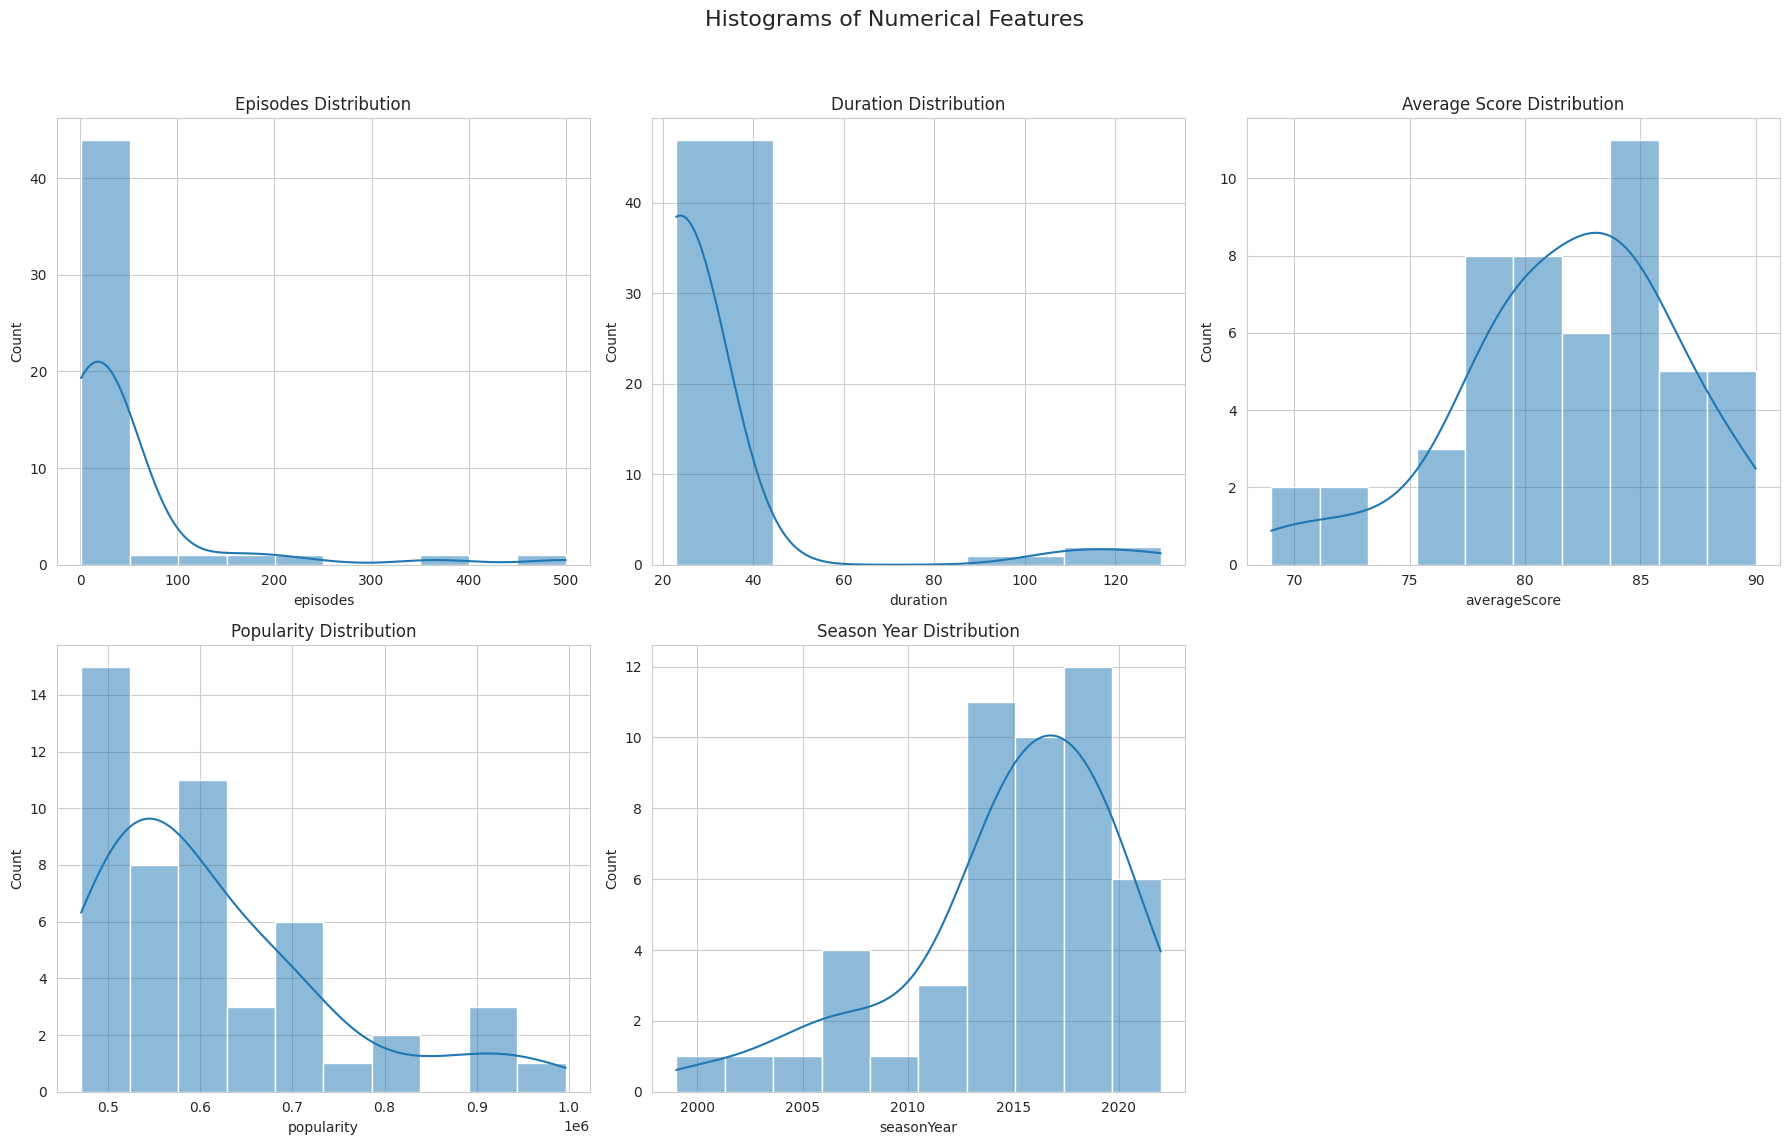

In [19]:
# Histograms for numerical features

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Histograms of Numerical Features', fontsize=16)

sns.histplot(df['episodes'], bins=10, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Episodes Distribution')

sns.histplot(df['duration'], bins=5, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Duration Distribution')

sns.histplot(df['averageScore'], bins=10, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Average Score Distribution')

sns.histplot(df['popularity'], bins=10, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Popularity Distribution')

sns.histplot(df['seasonYear'], bins=10, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Season Year Distribution')

fig.delaxes(axes[1, 2]) # Remove empty subplot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('histograms.png')
plt.show()

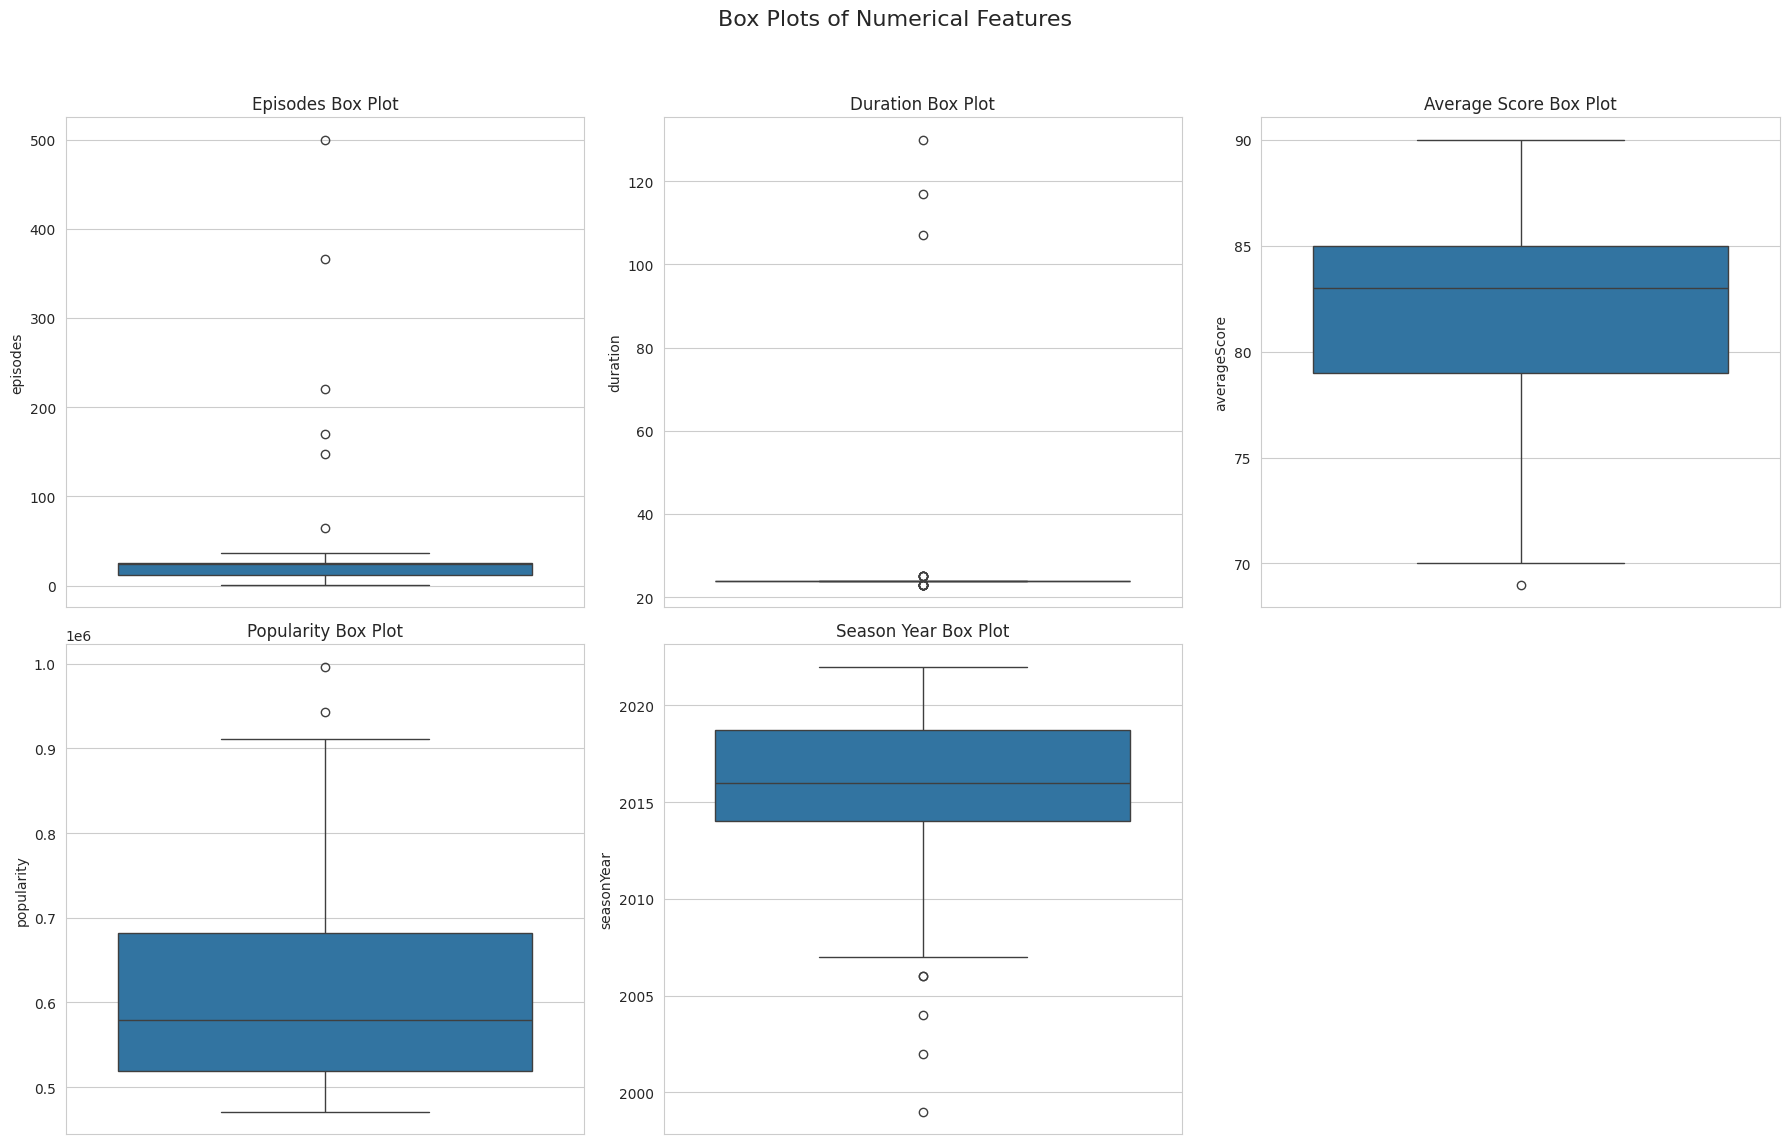

In [20]:
# Box plots for numerical features to identify outliers

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Box Plots of Numerical Features', fontsize=16)

sns.boxplot(y=df['episodes'], ax=axes[0, 0])
axes[0, 0].set_title('Episodes Box Plot')

sns.boxplot(y=df['duration'], ax=axes[0, 1])
axes[0, 1].set_title('Duration Box Plot')

sns.boxplot(y=df['averageScore'], ax=axes[0, 2])
axes[0, 2].set_title('Average Score Box Plot')

sns.boxplot(y=df['popularity'], ax=axes[1, 0])
axes[1, 0].set_title('Popularity Box Plot')

sns.boxplot(y=df['seasonYear'], ax=axes[1, 1])
axes[1, 1].set_title('Season Year Box Plot')

fig.delaxes(axes[1, 2]) # Remove empty subplot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('boxplots.png')
plt.show()

### Bar Charts for Categorical Features

Now, let's visualize the distributions of our categorical features: `format`, `status`, and `genres` using bar charts.

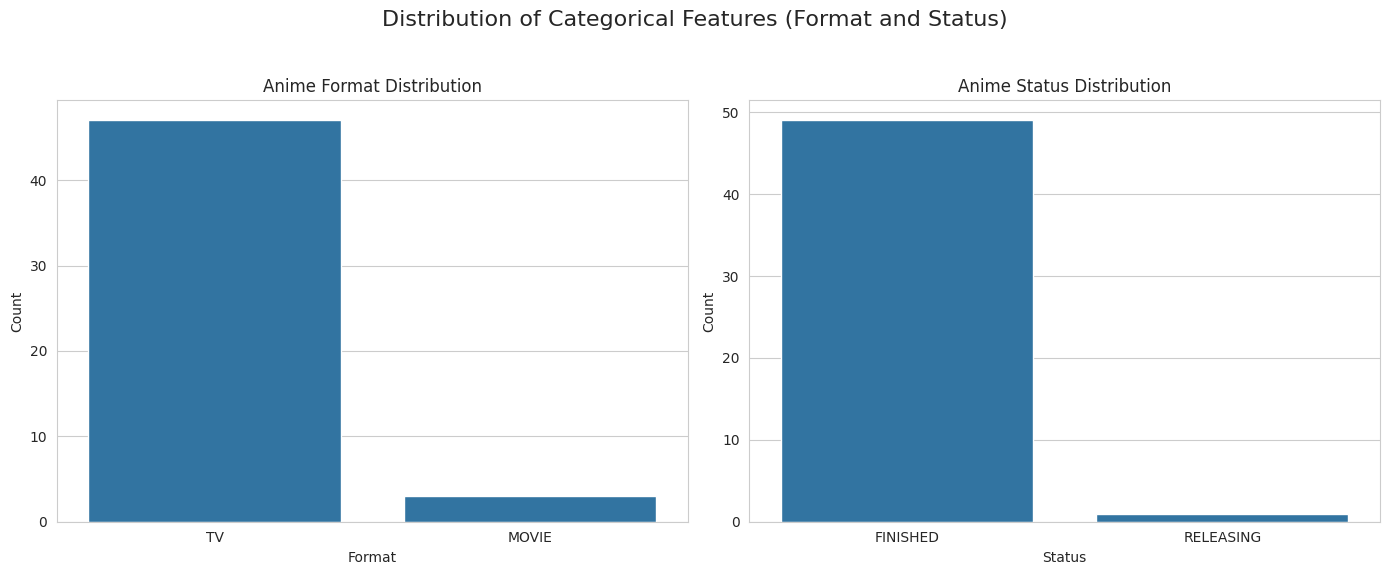

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle('Distribution of Categorical Features (Format and Status)', fontsize=16)

sns.countplot(x='format', data=df, ax=axes[0])
axes[0].set_title('Anime Format Distribution')
axes[0].set_xlabel('Format')
axes[0].set_ylabel('Count')

sns.countplot(x='status', data=df, ax=axes[1])
axes[1].set_title('Anime Status Distribution')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('categorical_counts.png')
plt.show()

/tmp/ipykernel_101555/355071975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=exploded_genres, order=exploded_genres.value_counts().index, palette='viridis')


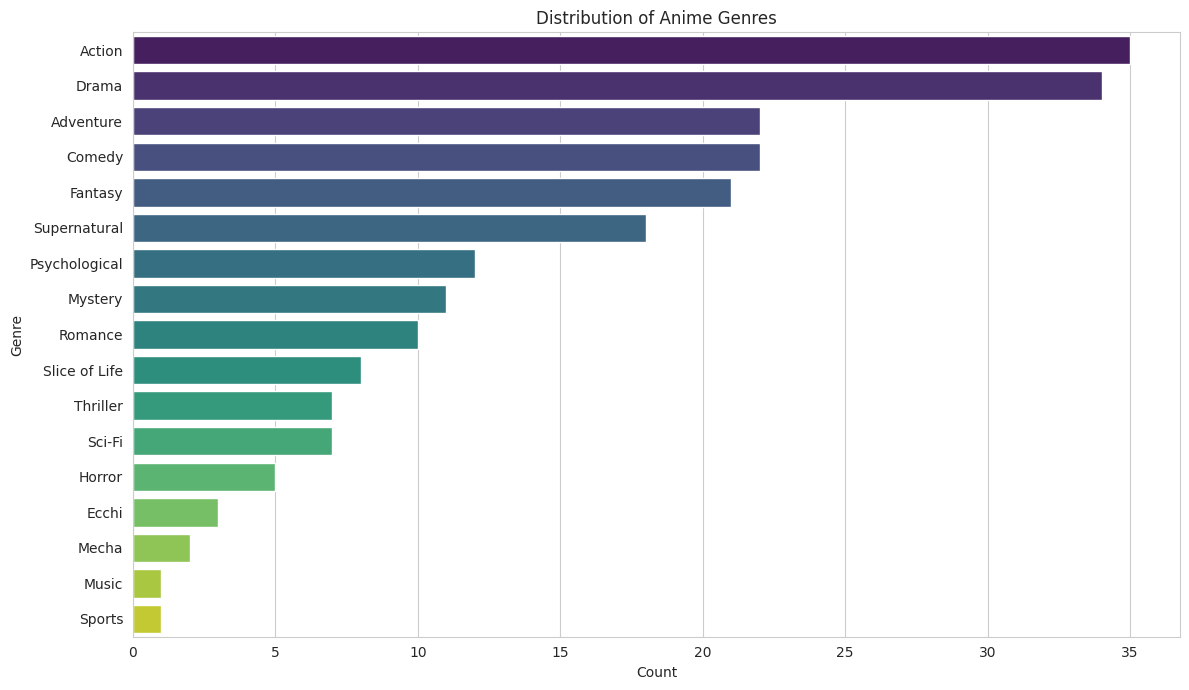

In [22]:
# Bar chart for genre distribution
plt.figure(figsize=(12, 7))
sns.countplot(y=exploded_genres, order=exploded_genres.value_counts().index, palette='viridis')
plt.title('Distribution of Anime Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_counts.png')
plt.show()

### Relationships Between Numerical Features (Scatter Plots and Correlation Heatmap)

Finally, let's look at how numerical features relate to each other. We'll use scatter plots for key relationships and a correlation heatmap for a broader view.

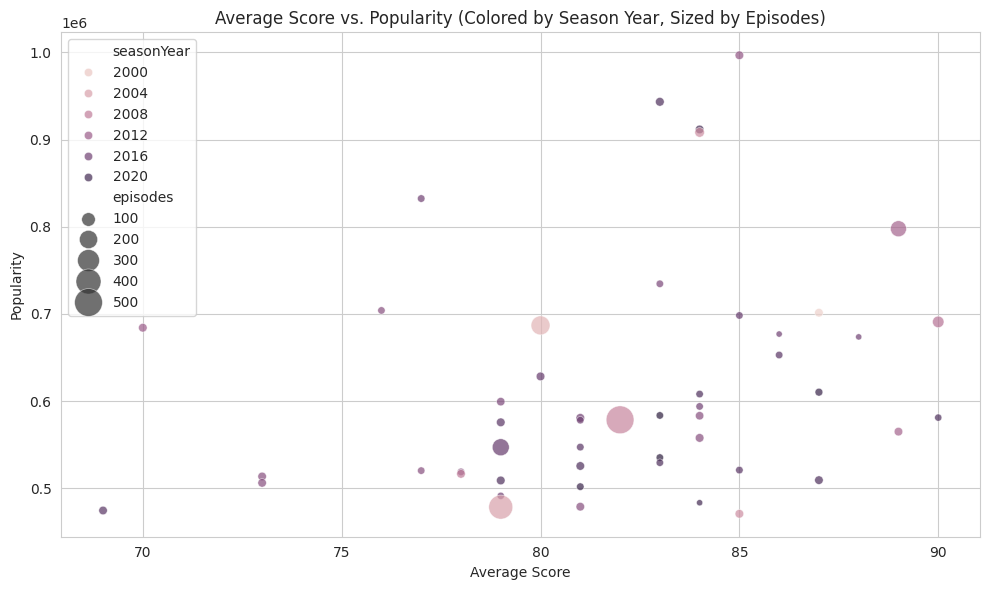

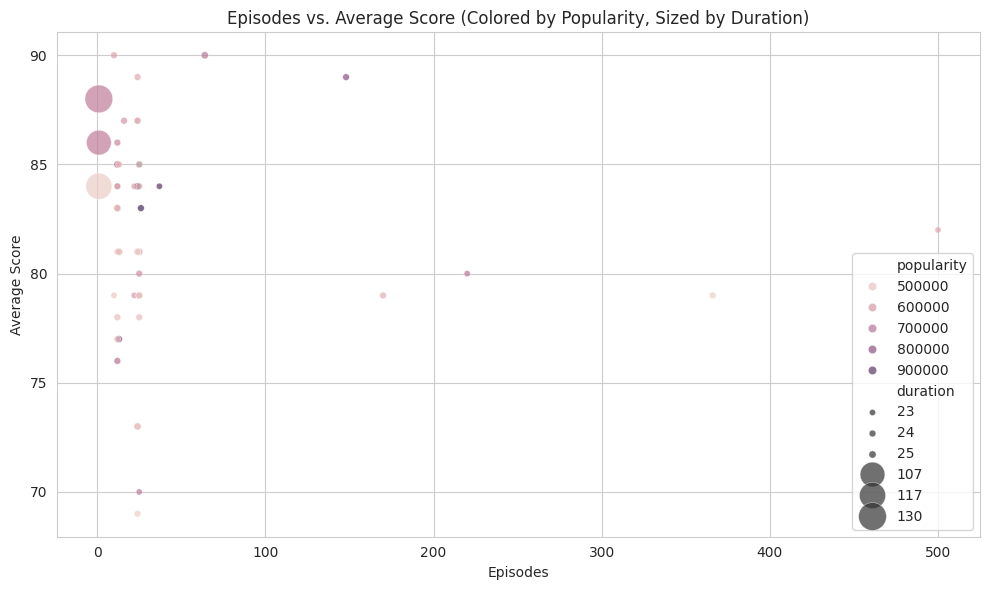

In [23]:
# Scatter plot: Average Score vs. Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='averageScore', y='popularity', data=df, hue='seasonYear', size='episodes', sizes=(20, 400), alpha=0.7)
plt.title('Average Score vs. Popularity (Colored by Season Year, Sized by Episodes)')
plt.xlabel('Average Score')
plt.ylabel('Popularity')
plt.grid(True)
plt.tight_layout()
plt.savefig('score_popularity_scatter.png')
plt.show()

# Scatter plot: Episodes vs. Average Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='episodes', y='averageScore', data=df, hue='popularity', size='duration', sizes=(20, 400), alpha=0.7)
plt.title('Episodes vs. Average Score (Colored by Popularity, Sized by Duration)')
plt.xlabel('Episodes')
plt.ylabel('Average Score')
plt.grid(True)
plt.tight_layout()
plt.savefig('episodes_score_scatter.png')
plt.show()

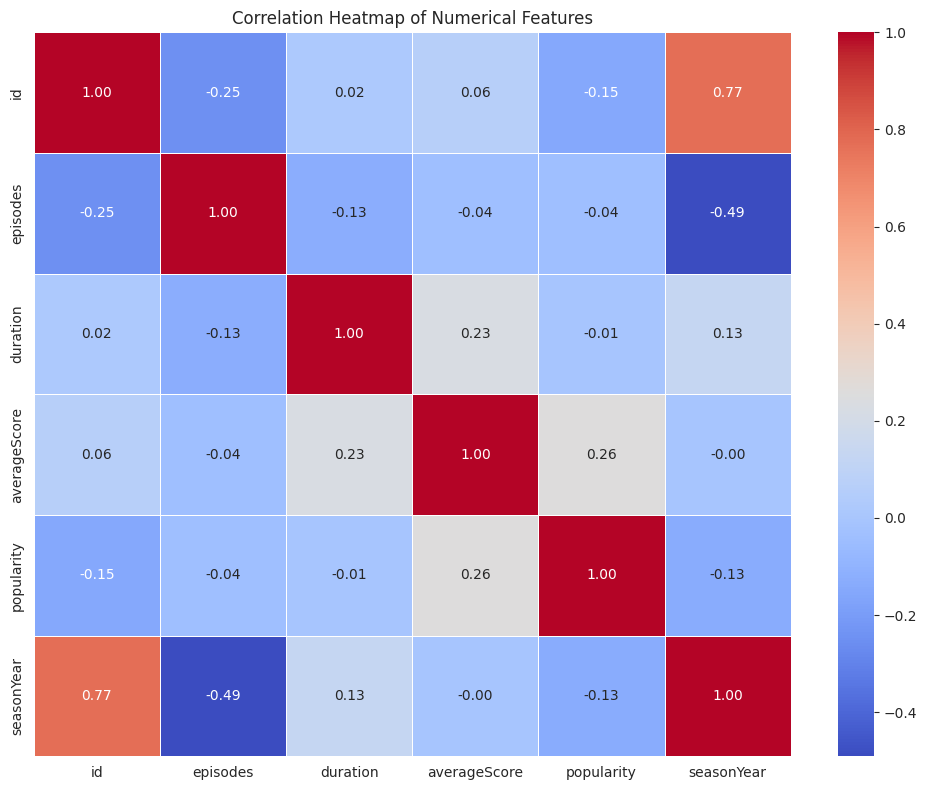

In [24]:
# Correlation Heatmap for numerical features

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Step 3: Exploratory Data Analysis (EDA) - Summary Statistics

Now that our data is clean, let's generate summary statistics for the numerical columns. This will provide insights into their distributions, central tendencies, and spread.

In [25]:
# Display descriptive statistics for numerical columns
display(df.describe())

,id,episodes,duration,averageScore,popularity,seasonYear
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000
mean,48600.260000,45.020000,29.580000,81.900000,614017.700000,2014.84000
std,46146.958493,90.644065,22.692343,4.734804,129256.366973,5.16013
min,20.000000,1.000000,23.000000,69.000000,470931.000000,1999.00000
25%,19973.000000,12.000000,24.000000,79.000000,519392.250000,2014.00000
50%,21218.000000,24.000000,24.000000,83.000000,579797.000000,2016.00000
75%,101333.750000,25.000000,24.000000,85.000000,682423.000000,2018.75000
max,140960.000000,500.000000,130.000000,90.000000,996584.000000,2022.00000


In [26]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64


In [27]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64
